# SalesPath — Colab Training Notebook   
## Trained this locally to check how 0.5B model beahves.
**Stack:** OpenEnv + GRPO (TRL) + Unsloth + Qwen 2.5

**Instructions:**
1. Runtime → Change runtime type → **T4 GPU**
2. Add `HF_TOKEN` in Colab Secrets (left sidebar 🔑)
3. Run **Cell 1** once (installs + clones)
4. Run **Cell 2** (starts server + validates)
5. Run **Cell 3** (curriculum training)
6. Run **Cell 4** (GRPO training)
7. Run **Cell 5** (reward graph)

In [1]:
# ============================================================
# CELL 1 — Install + Clone
# ============================================================
import os, sys, subprocess, time
from pathlib import Path

# ---------- CONFIG ----------
REPO_URL          = "https://github.com/Imsachin010/salespath_env.git"
MODEL_NAME        = "unsloth/Qwen2.5-7B-Instruct"   # 7B Model for final submission
ENV_URL           = "http://127.0.0.1:8000"
OUTPUT_DIR        = "/content/salespath_out"
# -----------------------------------------

def run(cmd, check=True, cwd=None):
    print(f"\n$ {cmd}")
    r = subprocess.run(cmd, shell=True, text=True, capture_output=True, cwd=cwd)
    if r.stdout: print(r.stdout.strip())
    if r.stderr: print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command failed ({r.returncode}): {cmd}")
    return r

!nvidia-smi
print("Python:", sys.version)

# Install dependencies
!pip install -q -U pip
!pip uninstall -y openenv 2>/dev/null || true
!pip install -q fastapi uvicorn pydantic httpx openenv-core torch transformers trl unsloth datasets pyarrow huggingface_hub matplotlib

# Clone repo
if not Path("/content/salespath_env").exists():
    run(f"git clone {REPO_URL} /content/salespath_env")
else:
    print("Repo already cloned.")

REPO_ROOT = "/content/salespath_env"
os.chdir(REPO_ROOT)
print("Working dir:", os.getcwd())

# Install package in editable mode
run("pip install -q -e .")
run("python -c \"import salespath_env; print('salespath_env import OK')\"")
run("python -c \"import openenv.core; print('openenv.core import OK')\"")

# HF Login
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    from huggingface_hub import login
    login(token=hf_token)
    print("HF login OK")
else:
    print("HF_TOKEN not set.")

print("\n✅ Setup complete.")

Sun Apr 26 08:16:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Pull the fix we just pushed
!git pull origin main

From https://github.com/Imsachin010/salespath_env
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
# ============================================================
# CELL 2 — Start Server + Validate
# ============================================================
import os, time, httpx
os.chdir("/content/salespath_env")

!pkill -f 'uvicorn salespath_env.server.app' 2>/dev/null || true
time.sleep(1)

!nohup python -m uvicorn salespath_env.server.app:app --host 0.0.0.0 --port 8000 > /content/server.log 2>&1 &
time.sleep(4)

healthy = False
for i in range(15):
    try:
        r = httpx.get("http://127.0.0.1:8000/health", timeout=5)
        if r.status_code == 200:
            print(f"✅ Server healthy: {r.text}")
            healthy = True
            break
    except Exception:
        pass
    time.sleep(2)
    print(f"  waiting... ({i+1}/15)")

if not healthy:
    print("\n--- server.log ---")
    !cat /content/server.log
    raise RuntimeError("Server failed to start! See logs above.")

reset_r = httpx.post("http://127.0.0.1:8000/reset", json={"difficulty": 1}, timeout=10)
print("\n/reset status:", reset_r.status_code)
print("✅ Server validation passed.")

^C
  waiting... (1/15)
✅ Server healthy: {"status":"healthy"}

/reset status: 200
✅ Server validation passed.


In [6]:
# Run the 0.5B model using our universal grpo_train.py
!python -m training.grpo_train \
    --mode grpo \
    --model-name Qwen/Qwen2.5-0.5B-Instruct \
    --grpo-steps 100 \
    --grpo-dataset-size 96 \
    --num-generations 4 \
    --max-completion-length 64 \
    --output-dir /content/salespath_out \
    --logging-steps 5

Launching TRL GRPO mode...
2026-04-26 08:19:52.447587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777191592.468134   34636 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777191592.475208   34636 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777191592.493185   34636 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777191592.493235   34636 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777191592.493240   34636 computation_placer.cc:

Saved reward graph → /content/salespath_out/reward_graph.png
  Episodes:    20
  Mean reward: 0.2317
  Max reward:  0.3488
  Min reward:  0.1300
  Std reward:  0.0554


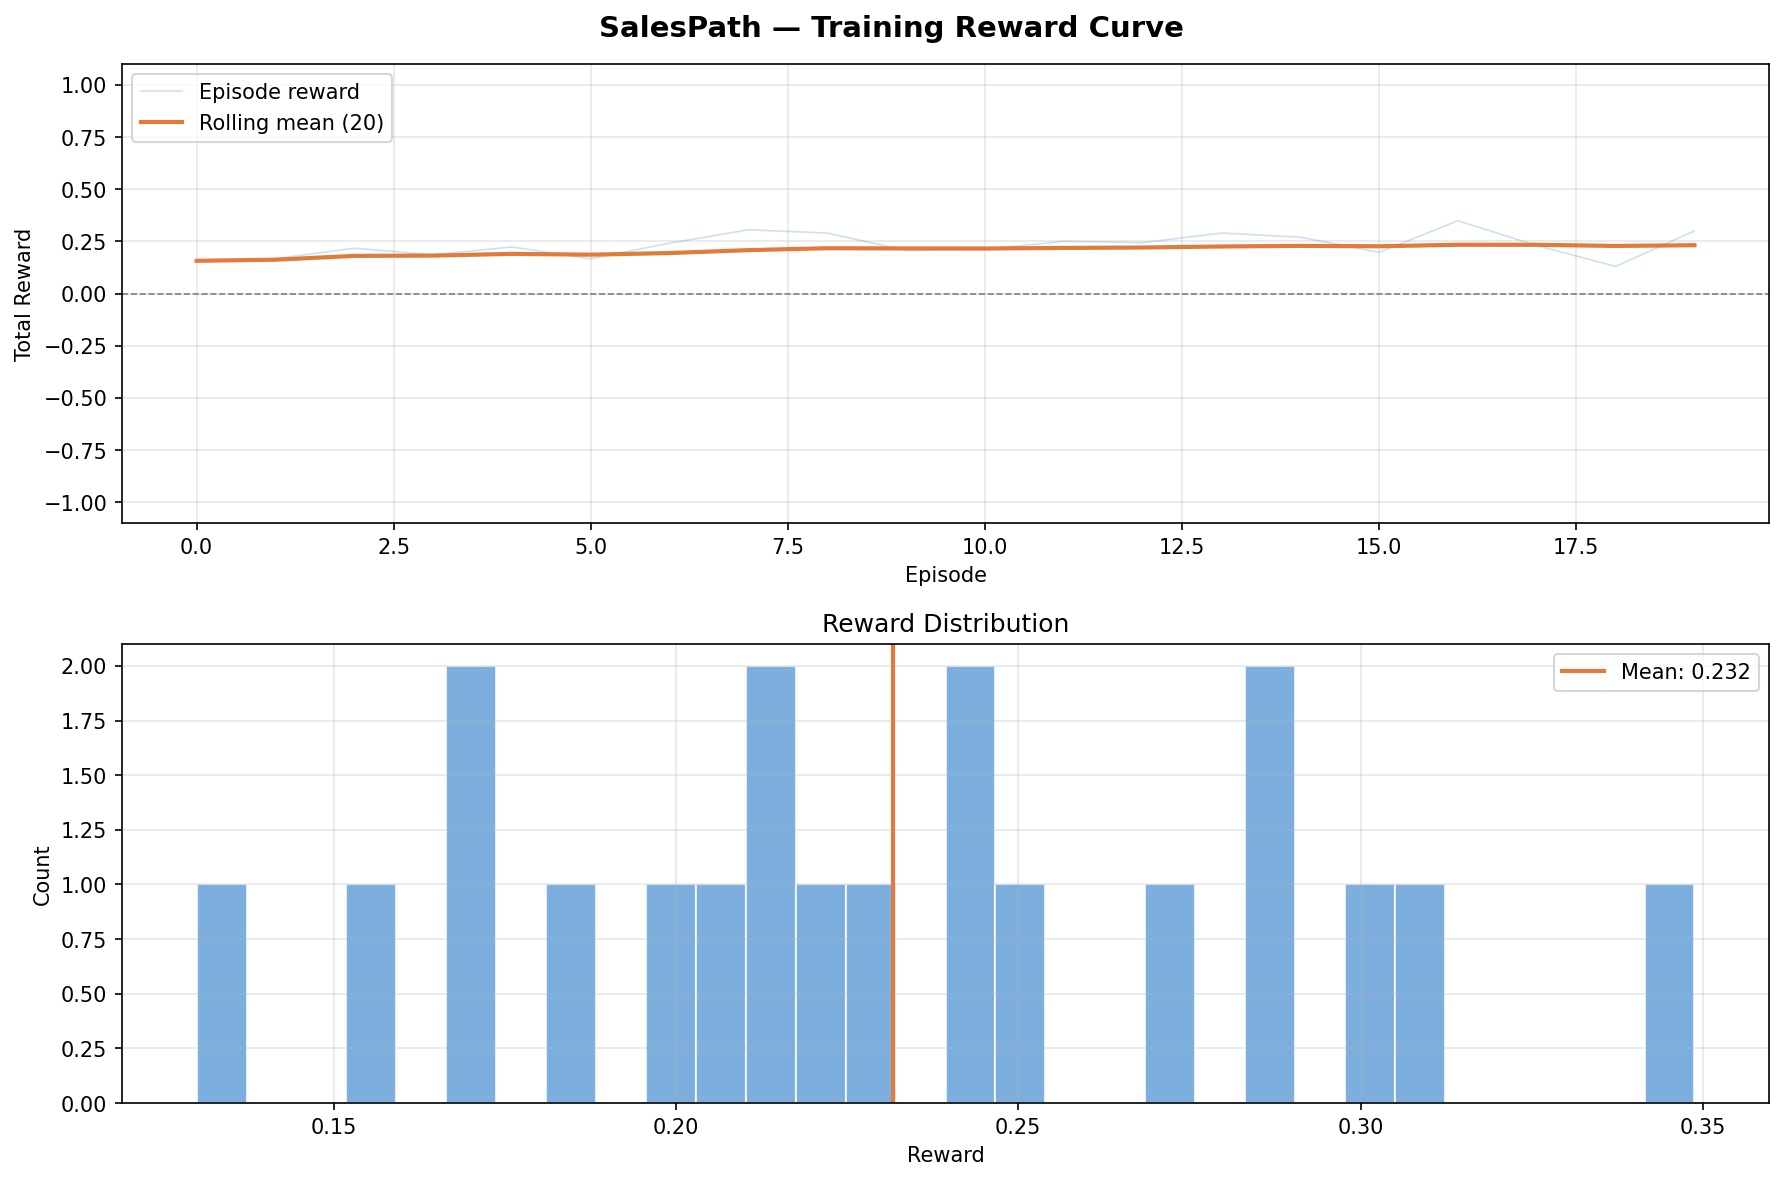

In [7]:
import os
os.chdir("/content/salespath_env")

# Generate the graph using the history file from the training output
!python training/plot_rewards.py \
    --input /content/salespath_out/reward_history.txt \
    --output /content/salespath_out/reward_graph.png

# Display the graph right here in the notebook
from IPython.display import Image
display(Image("/content/salespath_out/reward_graph.png"))

In [ ]:
# ============================================================
# CELL 3 — (Optional) Rollout Smoke Test
# ============================================================
# Skip this to save time if you already validated the environment.
# import os
# os.chdir("/content/salespath_env")
# !python -m training.test_rollout

In [ ]:
# ============================================================
# CELL 4 — (Optional) Curriculum Loop
# ============================================================
# Skip this. We will jump straight to GRPO for the 7B model.


In [ ]:
# ============================================================
# CELL 5 — GRPO Training (7B Model, Memory Safe)
# Initial Health Check: 150 Steps
# ============================================================
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.chdir("/content/salespath_env")

!PYTORCH_ALLOC_CONF=expandable_segments:True \
python -m training.grpo_train \
    --mode grpo \
    --model-name unsloth/Qwen2.5-7B-Instruct \
    --grpo-steps 150 \
    --grpo-dataset-size 128 \
    --num-generations 2 \
    --max-completion-length 128 \
    --per-device-train-batch-size 1 \
    --gradient-accumulation-steps 8 \
    --output-dir /content/salespath_out \
    --logging-steps 10

Launching TRL GRPO mode...
2026-04-26 07:11:29.087629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777187489.326359   17310 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777187489.397054   17310 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777187489.873542   17310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777187489.873617   17310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777187489.873622   17310 computation_placer.cc: